## Khai báo thư viện

In [14]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
data = pd.read_csv("datasets/DailyDelhiClimate_2013_2025.csv")

In [35]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Data Processing And Cleaning 

In [36]:
data.describe()

,meantemp,humidity,wind_speed,meanpressure
count,4749.000000,4749.000000,4749.000000,4749.000000
mean,25.521007,60.515002,6.876044,1008.935828
std,7.264789,17.147545,4.316583,101.119661
min,5.607385,10.000000,0.000000,-3.041667
25%,19.125000,49.562595,3.732064,1001.581877
50%,27.634758,62.314972,6.612846,1008.571429
75%,31.400000,72.622537,9.595772,1014.852198
max,41.518276,100.000000,42.220000,7679.333333


In [37]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4749 entries, 0 to 4748
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          4749 non-null   str    
 1   meantemp      4749 non-null   float64
 2   humidity      4749 non-null   float64
 3   wind_speed    4749 non-null   float64
 4   meanpressure  4749 non-null   float64
dtypes: float64(4), str(1)
memory usage: 185.6 KB


In [38]:
# Tổng số lượng giá trị bị thiếu
data.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [39]:
# Số chiều của bộ dữ liệu
data.shape

(4749, 5)

In [40]:
# Đếm tổng số bản ghi bị lặp
data.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

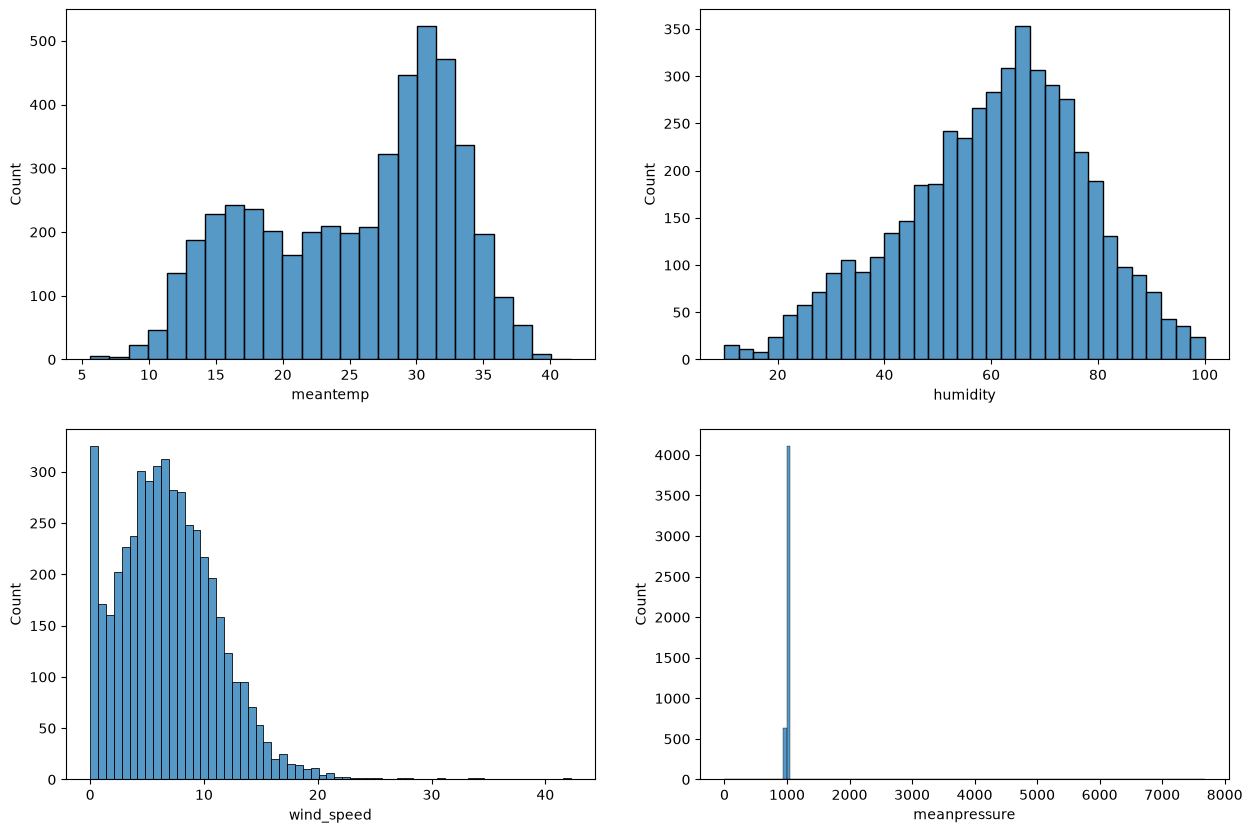

In [41]:
# Biểu đồ tần suất cho 4 trường thông tin của bộ dữ liệu
plt.figure(figsize=(15,10))
i=1
for col in data.iloc[:,1:5]:
    plt.subplot(2,2,i)
    sns.histplot(data[col])
    i=i+1

### 1. Chuẩn hóa dữ liệu thời gian:

In [42]:
data.index=pd.to_datetime(data.date)

In [43]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
date,,,,,
2013-01-01,2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,2013-01-05,6.000000,86.833333,3.700000,1016.500000


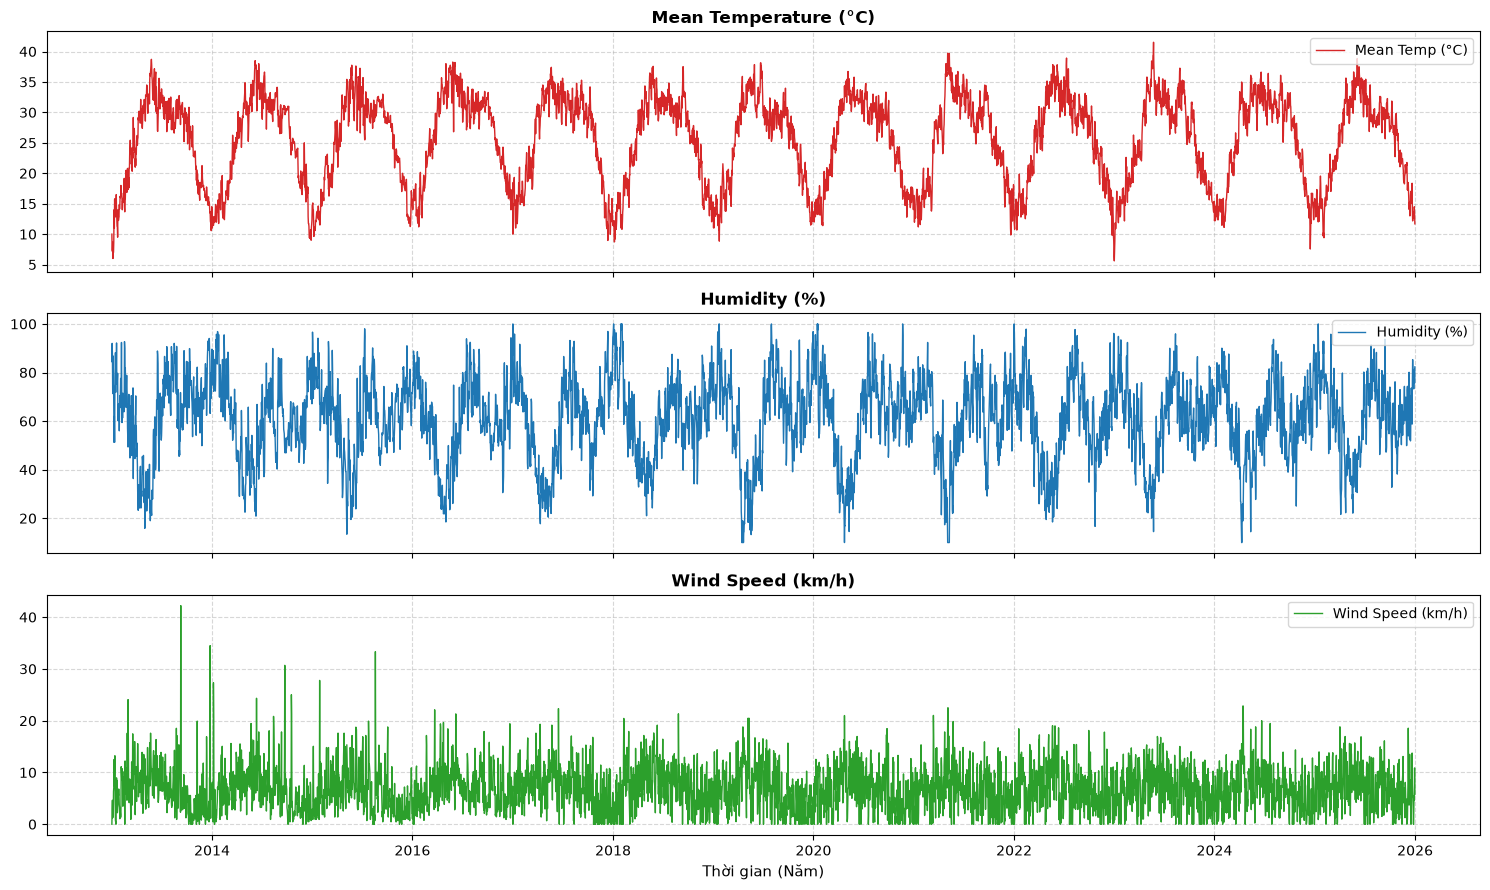

In [44]:
# Biểu đồ so sánh sự biến thiên của 3 chỉ số khí hậu (meantemp, humidity, wind_speed) theo thời gian
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

# 1. Nhiệt độ trung bình
axes[0].plot(data.index, data['meantemp'], color='#d62728', linewidth=1, label='Mean Temp (°C)')
axes[0].set_title('Mean Temperature (°C)', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right')

# 2. Độ ẩm
axes[1].plot(data.index, data['humidity'], color='#1f77b4', linewidth=1, label='Humidity (%)')
axes[1].set_title('Humidity (%)', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

# 3. Tốc độ gió
axes[2].plot(data.index, data['wind_speed'], color='#2ca02c', linewidth=1, label='Wind Speed (km/h)')
axes[2].set_title('Wind Speed (km/h)', fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right')

plt.xlabel('Thời gian (Năm)', fontsize=11)
plt.tight_layout()
plt.show()

=> Temperature (nhiệt độ) và Humidity (độ ẩm) tỷ lệ nghịch với nhau

### 2. Chuyển đổi datetime sang integer:

In [45]:
# Thêm tryiwngf thông tin day, hour, month
data['date'] = pd.to_datetime(data['date'])
data['day'] = data['date'].dt.day
data['hour'] = data['date'].dt.hour
data['month'] = data['date'].dt.month

In [46]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure,day,hour,month
date,,,,,,,,
2013-01-01,2013-01-01,10.000000,84.500000,0.000000,1015.666667,1,0,1
2013-01-02,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2,0,1
2013-01-03,2013-01-03,7.166667,87.000000,4.633333,1018.666667,3,0,1
2013-01-04,2013-01-04,8.666667,71.333333,1.233333,1017.166667,4,0,1
2013-01-05,2013-01-05,6.000000,86.833333,3.700000,1016.500000,5,0,1


### 3. Gom nhóm dữ liệu theo ngày:

In [48]:
# Tính giá trị trung bình theo ngày
data.groupby(by="day").mean(numeric_only=True)

,meantemp,humidity,wind_speed,meanpressure,hour,month
day,,,,,,
1,25.233241,62.421704,6.742894,1002.619826,0.0,6.464968
2,25.355423,61.725721,6.652557,1004.152645,0.0,6.500000
3,25.382015,61.122515,6.961008,1008.495635,0.0,6.500000
4,25.380891,61.084571,6.948625,1008.174452,0.0,6.500000
5,25.413627,61.084620,6.747209,1008.174696,0.0,6.500000
6,25.294478,61.316561,6.700002,1008.335153,0.0,6.500000
7,25.254207,61.032875,7.023864,1008.339891,0.0,6.500000
8,25.359715,59.862559,7.047909,1008.248987,0.0,6.500000
9,25.495321,59.764305,7.201427,1007.576526,0.0,6.500000


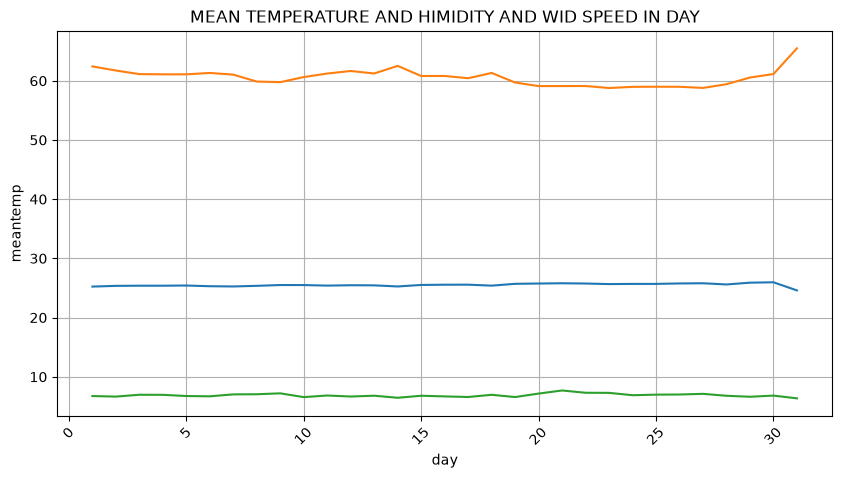

In [51]:
# Biểu đồ thể hiện mối tương quan giữa MeanTemp (Nhiệt độ), Humidity (độ ẩm), WindSpeed (sức gió) theo ngày
plt.figure(figsize=(10,5))
plt.title("MEAN TEMPERATURE AND HIMIDITY AND WID SPEED IN DAY")
sns.lineplot(data.groupby(by="day")['meantemp'].mean())
sns.lineplot(data.groupby(by="day")['humidity'].mean())
sns.lineplot(data.groupby(by="day")['wind_speed'].mean())
plt.xticks(rotation=45)
plt.grid()
plt.show()

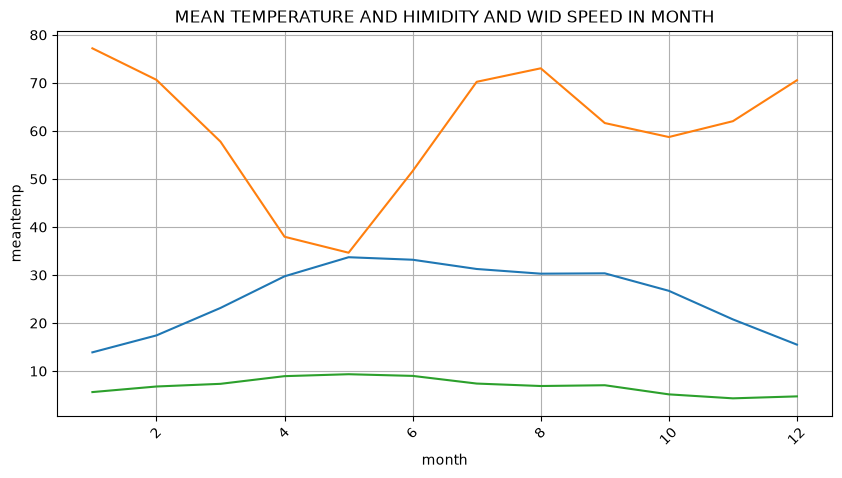

In [52]:
# Biểu đồ thể hiện mối tương quan giữa MeanTemp (Nhiệt độ), Humidity (độ ẩm), WindSpeed (sức gió) theo tháng
plt.figure(figsize=(10,5))
plt.title("MEAN TEMPERATURE AND HIMIDITY AND WID SPEED IN MONTH")
sns.lineplot(data.groupby(by="month")['meantemp'].mean())
sns.lineplot(data.groupby(by="month")['humidity'].mean())
sns.lineplot(data.groupby(by="month")['wind_speed'].mean())
plt.xticks(rotation=45)
plt.grid()
plt.show()

### 4. Xu hướng nhiệt độ trung bình theo năm:

In [53]:
# Đánh index cho 'meantemp'
tempdata=data[['meantemp']]
tempdata.index=pd.to_datetime(data.date)

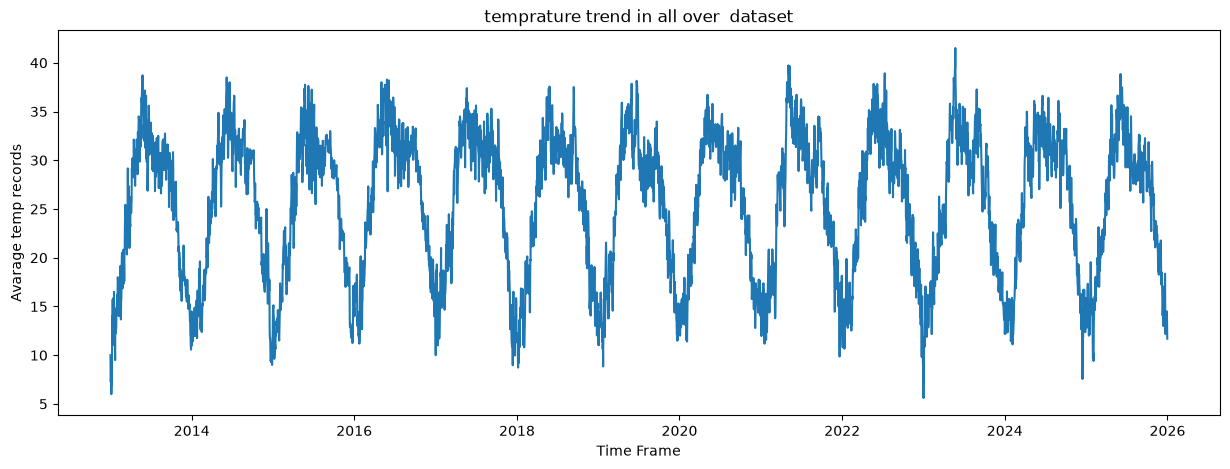

In [54]:
# Biểu đồ xu hướng nhiệt độ theo từng năm
plt.figure(figsize=(15,5))
plt.xlabel("Time Frame")
plt.ylabel("Avarage temp records")
plt.title("temprature trend in all over  dataset")
plt.plot(tempdata)
plt.show()

### 5. Ma trận tương quan của bộ dữ liệu:

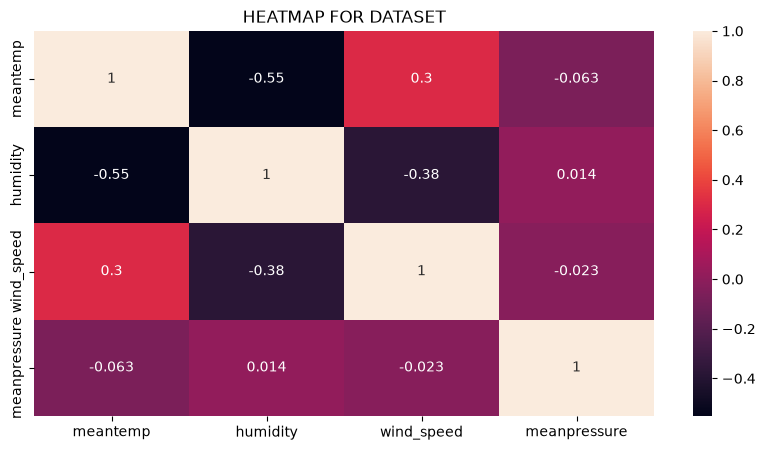

In [55]:
plt.figure(figsize=(10,5))
plt.title("HEATMAP FOR DATASET")
sns.heatmap(data.iloc[:,1:5].corr(),annot=True);
plt.show()

## Phân tích chuỗi thời gian Time Series